Predicción de notas según horas de estudio — Regresión Lineal

Descripción
Modelo de regresión lineal simple para predecir la nota que obtendrá un estudiante en un examen según las horas de estudio realizadas. Incluye generación de datos sintéticos, limpieza, análisis exploratorio, entrenamiento del modelo y visualización de resultados.

In [21]:
# importación de bibliotecas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# carga de los datos
data = pd.read_csv('study_hours.csv')
data

,nombre,apellido,edad,sexo,horas_estudio,nota
0,José,Fernández,18,M,2,45.37
1,Pedro,López,20,F,2,53.61
2,Carlos,Ruiz,19,M,9,100.00
3,Ana,Rodríguez,20,M,5,52.96
4,Luis,Fernández,22,M,4,55.08
...,...,...,...,...,...,...
495,Laura,Martínez,21,M,6,70.77
496,Elena,Hernández,21,M,5,62.78
497,Miguel,Ruiz,20,F,2,60.49
498,Carlos,Gómez,22,M,1,54.52


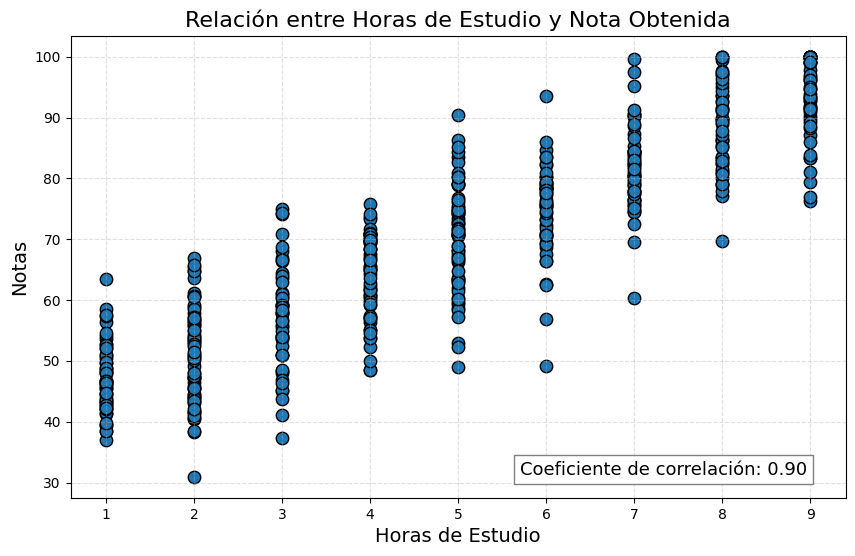

In [ ]:
# variables necesarias para la prediccion 
x = data[['horas_estudio']]
y = data['nota']

# coeficiente de correlación entre las variables
coefCorr = np.corrcoef(data['horas_estudio'], y)[0, 1]

# Grafico de dispersion (scatter plot) para medir y ver la correlacion entre las variables
plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(x, y, s=80, color='#1f77b4', edgecolor='black')

# Etiquetas
plt.xlabel('Horas de Estudio', fontsize=14)
plt.ylabel('Notas', fontsize=14)
plt.title('Relación entre Horas de Estudio y Nota Obtenida', fontsize=16)

# Texto del coeficiente de correlación
plt.text(
    0.95, 0.05,
    f'Coeficiente de correlación: {coefCorr:.2f}',
    fontsize=13,
    color='black',
    ha='right',
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', edgecolor='gray')
)

# Mejor estilo visual
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


In [30]:
# Existe alta correlación entre las variables, por lo que podemos aplicar un modelo de regresión lineal para predecir la nota obtenida en función de las horas de estudio.

# division de los datos en conjunto de entrenamiento y prueba
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# creación del modelo de regresión lineal
model = LinearRegression()

# entrenamiento del modelo
model.fit(x_train,y_train)

predicciones = model.predict(x_test)

ECM = mean_squared_error(y_test,predicciones)
R2 = r2_score(y_test,predicciones)

print(f'Error Cuadrático Medio (ECM): {ECM:.2f}')
print(f'Coeficiente de Determinación (R²): {R2:.2f}')

Error Cuadrático Medio (ECM): 56.08
Coeficiente de Determinación (R²): 0.81


In [37]:
# generación de datos sintéticos para predecir y probar el modelo
horas_estudio_nuevas = np.array([[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
predicciones_nuevas = model.predict(horas_estudio_nuevas).astype(int)
print(predicciones_nuevas)

[40 46 52 58 63 69 75 81 87 93 99]


c:\Users\HOME\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


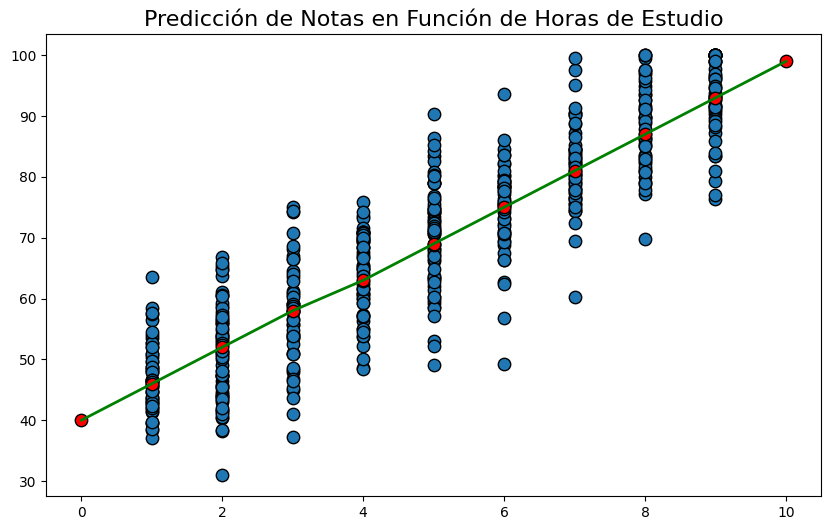

In [39]:
# Visualización de los nuevos datos y sus predicciones en el grafico
plt.figure(figsize=(10,6))
plt.scatter(x,y, s=80, color='#1f77b4', edgecolor='black')
plt.scatter(horas_estudio_nuevas, predicciones_nuevas, s=80, color='red', edgecolor='black')
plt.plot(horas_estudio_nuevas, predicciones_nuevas, color='green', linewidth=2)
plt.title('Predicción de Notas en Función de Horas de Estudio', fontsize=16)
plt.show()